## 1. Module Import
The below listed modules are nessesary for various purposes
1. `os` - for using various os related funtionalities such as `makedir`
2. `Path` - for retriving files present inside other directory
3. `pyedflib` - for converting the numpy files into edf
4. `numpy` - for numerical calculations on edf files
5. `mne` - for reading the edf files
6. `gc` - for collecting and deleting garbage memory

In [ ]:
import os
from pathlib import Path
import pyedflib
import numpy as np
import mne
import gc

## 1. Data Analysis
### 1.1 Looking at CHB-MIT Data
For better understanding of the data and visualisation of data using the `mne` module, reading one instance of CHB-MIT dataset

Extracting EDF parameters from ../data/raw/CHB-MIT/chb01/chb01_01.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 921599  =      0.000 ...  3599.996 secs...
<Info | 8 non-empty values
 bads: []
 ch_names: FP1-F7, F7-T7, T7-P7, P7-O1, FP1-F3, F3-C3, C3-P3, P3-O1, ...
 chs: 23 EEG
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 128.0 Hz
 meas_date: 2076-11-06 11:42:54 UTC
 nchan: 23
 projs: []
 sfreq: 256.0 Hz
 subject_info: <subject_info | his_id: Surrogate>
>
['FP1-F7', 'F7-T7', 'T7-P7', 'P7-O1', 'FP1-F3', 'F3-C3', 'C3-P3', 'P3-O1', 'FP2-F4', 'F4-C4', 'C4-P4', 'P4-O2', 'FP2-F8', 'F8-T8', 'T8-P8-0', 'P8-O2', 'FZ-CZ', 'CZ-PZ', 'P7-T7', 'T7-FT9', 'FT9-FT10', 'FT10-T8', 'T8-P8-1']
Using matplotlib as 2D backend.


C:\Users\Bul\AppData\Local\Temp\ipykernel_9460\4238778023.py:3: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  chb_raw = mne.io.read_raw_edf('../data/raw/CHB-MIT/chb01/chb01_01.edf', preload=True)


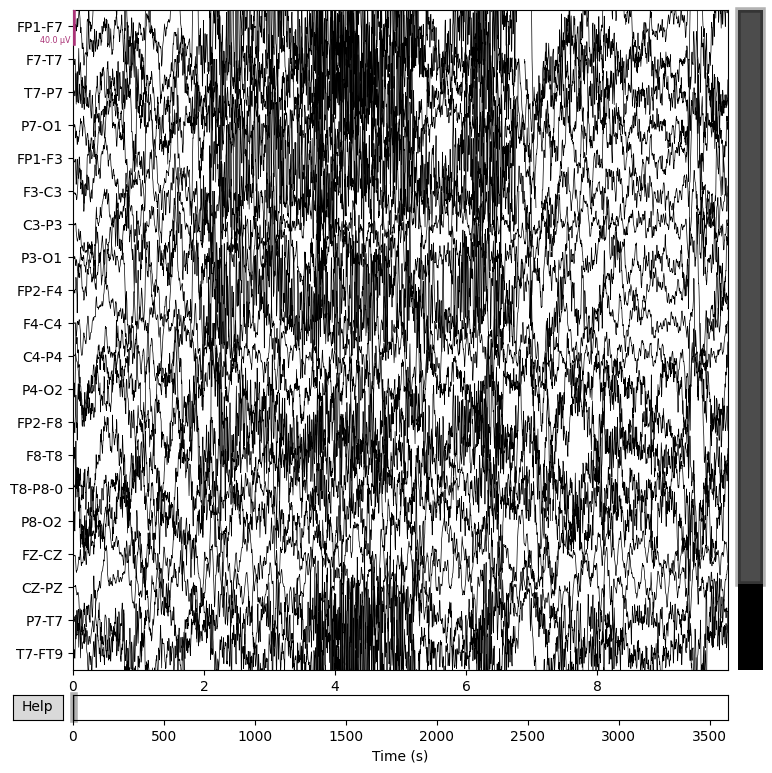

In [1]:
import mne
# Load one EDF file and inspect it
chb_raw = mne.io.read_raw_edf('../data/raw/CHB-MIT/chb01/chb01_01.edf', preload=True)
print(chb_raw.info)          # channels, sampling rate, duration
chb_channel_names = chb_raw.ch_names
print(chb_raw.ch_names)      # channel names
dump_extra_plot = chb_raw.plot(proj=False)               # visualize the raw signal

### 1.2 Looking at Seina Scalp Dataset
Continuing the data-analysis and visualisation by observing one instance from the SienaScalp EEG dataset.

Extracting EDF parameters from ../data/raw/SienaScalp/PN00/PN00-1.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 1343999  =      0.000 ...  2624.998 secs...


C:\Users\Bul\AppData\Local\Temp\ipykernel_9460\4126194348.py:4: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  seina_raw = mne.io.read_raw_edf('../data/raw/SienaScalp/PN00/PN00-1.edf', preload=True)
C:\Users\Bul\AppData\Local\Temp\ipykernel_9460\4126194348.py:4: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  seina_raw = mne.io.read_raw_edf('../data/raw/SienaScalp/PN00/PN00-1.edf', preload=True)
C:\Users\Bul\AppData\Local\Temp\ipykernel_9460\4126194348.py:4: RuntimeWarning: Highpass cutoff frequency 15.91549 is greater than lowpass cutoff frequency 15.0, setting values to 0 and Nyquist.
  seina_raw = mne.io.read_raw_edf('../data/raw/SienaScalp/PN00/PN00-1.edf', preload=True)


<Info | 8 non-empty values
 bads: []
 ch_names: EEG Fp1, EEG F3, EEG C3, EEG P3, EEG O1, EEG F7, EEG T3, EEG T5, ...
 chs: 35 EEG
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 256.0 Hz
 meas_date: 2016-01-01 19:39:33 UTC
 nchan: 35
 projs: []
 sfreq: 512.0 Hz
 subject_info: <subject_info | his_id: >
>
['EEG Fp1', 'EEG F3', 'EEG C3', 'EEG P3', 'EEG O1', 'EEG F7', 'EEG T3', 'EEG T5', 'EEG Fc1', 'EEG Fc5', 'EEG Cp1', 'EEG Cp5', 'EEG F9', 'EEG Fz', 'EEG Cz', 'EEG Pz', 'EEG Fp2', 'EEG F4', 'EEG C4', 'EEG P4', 'EEG O2', 'EEG F8', 'EEG T4', 'EEG T6', 'EEG Fc2', 'EEG Fc6', 'EEG Cp2', 'EEG Cp6', 'EEG F10', 'EKG EKG', 'SPO2', 'HR', '1', '2', 'MK']


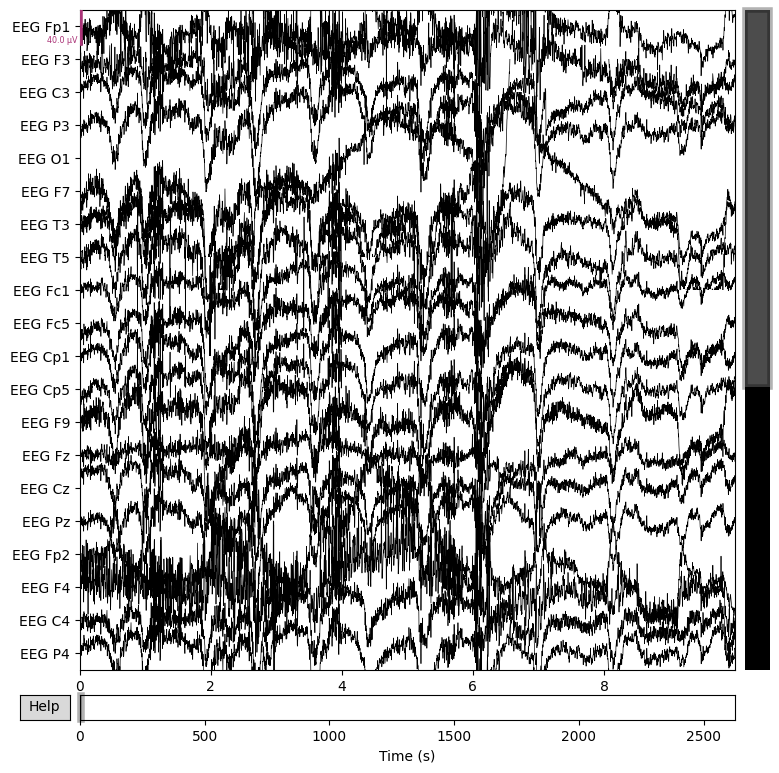

In [2]:
import mne

# Load one EDF file and inspect it
seina_raw = mne.io.read_raw_edf('../data/raw/SienaScalp/PN00/PN00-1.edf', preload=True)
print(seina_raw.info)          # channels, sampling rate, duration
seina_channel_names = seina_raw.ch_names
print(seina_raw.ch_names)      # channel names
dump_extra_plot = seina_raw.plot(proj=False)               # visualize the raw signal

### 1.3 Printing channels
Checking for common channels in the dataset for further processing.

In [3]:
print(seina_channel_names)
print(chb_channel_names)

['EEG Fp1', 'EEG F3', 'EEG C3', 'EEG P3', 'EEG O1', 'EEG F7', 'EEG T3', 'EEG T5', 'EEG Fc1', 'EEG Fc5', 'EEG Cp1', 'EEG Cp5', 'EEG F9', 'EEG Fz', 'EEG Cz', 'EEG Pz', 'EEG Fp2', 'EEG F4', 'EEG C4', 'EEG P4', 'EEG O2', 'EEG F8', 'EEG T4', 'EEG T6', 'EEG Fc2', 'EEG Fc6', 'EEG Cp2', 'EEG Cp6', 'EEG F10', 'EKG EKG', 'SPO2', 'HR', '1', '2', 'MK']
['FP1-F7', 'F7-T7', 'T7-P7', 'P7-O1', 'FP1-F3', 'F3-C3', 'C3-P3', 'P3-O1', 'FP2-F4', 'F4-C4', 'C4-P4', 'P4-O2', 'FP2-F8', 'F8-T8', 'T8-P8-0', 'P8-O2', 'FZ-CZ', 'CZ-PZ', 'P7-T7', 'T7-FT9', 'FT9-FT10', 'FT10-T8', 'T8-P8-1']


## 2. Preprocessing Data
As per the above obtained data, it is observed that there are few dicrepency in the dataset.
1. No common channels as **CHB-MIT** is a bipolar dataset and **SienaScalp** is a monopolar dataset
2. No common frequecy for both the datsets as **CHB-MIT** was recorded at `256 Hz` and **SienaScalp** was recorded at `512 Hz`

### 2.1 Converting Seina Dataset from  Monopolar to Bipoloar

In [ ]:
# Define bipolar pairs (based on CHB-MIT)
bipolar_pairs = [
    ('EEG Fp1', 'EEG F7'),
    ('EEG F7',  'EEG T3'),
    ('EEG T3',  'EEG T5'),
    ('EEG T5',  'EEG O1'),

    ('EEG Fp1', 'EEG F3'),
    ('EEG F3',  'EEG C3'),
    ('EEG C3',  'EEG P3'),
    ('EEG P3',  'EEG O1'),

    ('EEG Fp2', 'EEG F4'),
    ('EEG F4',  'EEG C4'),
    ('EEG C4',  'EEG P4'),
    ('EEG P4',  'EEG O2'),

    ('EEG Fp2', 'EEG F8'),
    ('EEG F8',  'EEG T4'),
    ('EEG T4',  'EEG T6'),
    ('EEG T6',  'EEG O2'),

    ('EEG Fz',  'EEG Cz'),
    ('EEG Cz',  'EEG Pz'),
]

seina_input_dir  = '../data/raw/SienaScalp'
seina_output_dir = '../data/processed/Seina'
os.makedirs(seina_output_dir, exist_ok=True)

for patient_dir in sorted(os.listdir(seina_input_dir)):
    patient_path = os.path.join(seina_input_dir, patient_dir)
    if not os.path.isdir(patient_path):
        continue

    patient_output_dir = os.path.join(seina_output_dir, patient_dir)
    os.makedirs(patient_output_dir, exist_ok=True)

    for edf_file in sorted(os.listdir(patient_path)):
        if not edf_file.endswith('.edf'):
            continue

        input_file = os.path.join(patient_path, edf_file)
        print(f"\nProcessing: {input_file}")

        try:
            raw = mne.io.read_raw_edf(input_file, preload=False, verbose=False)
            raw.resample(128, npad="auto")
            raw.load_data()
        except Exception as e:
            print(f"  Failed to load {edf_file}: {e}")
            continue

        # Build a set of available channels for O(1) lookup
        available_channels = set(raw.ch_names)

        bipolar = raw.copy()
        skipped = []

        for anode, cathode in bipolar_pairs:
            ch_name = f"{anode.split()[-1].upper()}-{cathode.split()[-1].upper()}"

            # Pre-flight check — skip if either channel absent in this file
            if anode not in available_channels:
                skipped.append((ch_name, anode))
                continue
            if cathode not in available_channels:
                skipped.append((ch_name, cathode))
                continue

            try:
                mne.set_bipolar_reference(
                    bipolar,
                    anode=anode,
                    cathode=cathode,
                    ch_name=ch_name,
                    drop_refs=False,
                    copy=False
                )
            except ValueError as e:
                print(f"  Skipping {ch_name}: {e}")
            except MemoryError:
                print(f"  MemoryError on {ch_name}, skipping.")

        if skipped:
            print(f"  Skipped {len(skipped)} pair(s) — channel not in file:")
            for ch_name, missing_ch in skipped:
                print(f"    {ch_name:12s} → '{missing_ch}' not found")

        # Pick only the successfully created bipolar channels
        bipolar_ch = [ch for ch in bipolar.ch_names if '-' in ch]

        if not bipolar_ch:
            print(f"  No bipolar channels extracted, skipping file.")
            del raw, bipolar
            gc.collect()
            continue

        bipolar.pick_channels(bipolar_ch)
        print(f"  Extracted {len(bipolar_ch)} bipolar channel(s): {bipolar_ch}")

        # Save as EDF
        output_file = os.path.join(patient_output_dir, edf_file)
        data        = bipolar.get_data() * 1e6   # V → µV
        sfreq       = int(bipolar.info['sfreq'])
        channel_names = bipolar.ch_names

        edf = pyedflib.EdfWriter(
            output_file,
            n_channels=len(channel_names),
            file_type=pyedflib.FILETYPE_EDFPLUS
        )

        channel_info = [
            {
                'label':            ch,
                'dimension':        'uV',
                'sample_frequency': sfreq,
                'physical_min':     -5000,
                'physical_max':      5000,
                'digital_min':      -32768,
                'digital_max':       32767,
                'transducer':       'EEG',
                'prefilter':        'HP:0.5Hz LP:70Hz'
            }
            for ch in channel_names
        ]

        edf.setSignalHeaders(channel_info)
        edf.writeSamples(data)
        edf.close()

        del raw, bipolar, data
        gc.collect()

        print(f"  Saved → {output_file}")


Processing: ../data/raw/SienaScalp\PN00\PN00-1.edf


C:\Users\Bul\AppData\Local\Temp\ipykernel_9460\2444066482.py:54: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf(input_file, preload=False, verbose=False)
C:\Users\Bul\AppData\Local\Temp\ipykernel_9460\2444066482.py:54: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw = mne.io.read_raw_edf(input_file, preload=False, verbose=False)
C:\Users\Bul\AppData\Local\Temp\ipykernel_9460\2444066482.py:54: RuntimeWarning: Highpass cutoff frequency 15.91549 is greater than lowpass cutoff frequency 15.0, setting values to 0 and Nyquist.
  raw = mne.io.read_raw_edf(input_file, preload=False, verbose=False)


EEG channel type selected for re-referencing
Creating RawArray with float64 data, n_channels=1, n_times=336000
    Range : 0 ... 335999 =      0.000 ...  2624.992 secs
Ready.
Added the following bipolar channels:
FP1-F7
EEG channel type selected for re-referencing
Creating RawArray with float64 data, n_channels=1, n_times=336000
    Range : 0 ... 335999 =      0.000 ...  2624.992 secs
Ready.
Added the following bipolar channels:
F7-T3
EEG channel type selected for re-referencing
Creating RawArray with float64 data, n_channels=1, n_times=336000
    Range : 0 ... 335999 =      0.000 ...  2624.992 secs
Ready.
Added the following bipolar channels:
T3-T5
EEG channel type selected for re-referencing
Creating RawArray with float64 data, n_channels=1, n_times=336000
    Range : 0 ... 335999 =      0.000 ...  2624.992 secs
Ready.
Added the following bipolar channels:
T5-O1
EEG channel type selected for re-referencing
Creating RawArray with float64 data, n_channels=1, n_times=336000
    Range : 

C:\Users\Bul\AppData\Local\Temp\ipykernel_9460\2444066482.py:54: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf(input_file, preload=False, verbose=False)
C:\Users\Bul\AppData\Local\Temp\ipykernel_9460\2444066482.py:54: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw = mne.io.read_raw_edf(input_file, preload=False, verbose=False)
C:\Users\Bul\AppData\Local\Temp\ipykernel_9460\2444066482.py:54: RuntimeWarning: Highpass cutoff frequency 15.91549 is greater than lowpass cutoff frequency 15.0, setting values to 0 and Nyquist.
  raw = mne.io.read_raw_edf(input_file, preload=False, verbose=False)


EEG channel type selected for re-referencing
Creating RawArray with float64 data, n_channels=1, n_times=294656
    Range : 0 ... 294655 =      0.000 ...  2301.992 secs
Ready.
Added the following bipolar channels:
FP1-F7
EEG channel type selected for re-referencing
Creating RawArray with float64 data, n_channels=1, n_times=294656
    Range : 0 ... 294655 =      0.000 ...  2301.992 secs
Ready.
Added the following bipolar channels:
F7-T3
EEG channel type selected for re-referencing
Creating RawArray with float64 data, n_channels=1, n_times=294656
    Range : 0 ... 294655 =      0.000 ...  2301.992 secs
Ready.
Added the following bipolar channels:
T3-T5
EEG channel type selected for re-referencing
Creating RawArray with float64 data, n_channels=1, n_times=294656
    Range : 0 ... 294655 =      0.000 ...  2301.992 secs
Ready.
Added the following bipolar channels:
T5-O1
EEG channel type selected for re-referencing
Creating RawArray with float64 data, n_channels=1, n_times=294656
    Range : 

...

EEG channel type selected for re-referencing
Creating RawArray with float64 data, n_channels=1, n_times=1190016
    Range : 0 ... 1190015 =      0.000 ...  9296.992 secs
Ready.
Added the following bipolar channels:
FP1-F7
EEG channel type selected for re-referencing
Creating RawArray with float64 data, n_channels=1, n_times=1190016
    Range : 0 ... 1190015 =      0.000 ...  9296.992 secs
Ready.
Added the following bipolar channels:
F7-T3
EEG channel type selected for re-referencing
Creating RawArray with float64 data, n_channels=1, n_times=1190016
    Range : 0 ... 1190015 =      0.000 ...  9296.992 secs
Ready.
Added the following bipolar channels:
T3-T5
EEG channel type selected for re-referencing
Creating RawArray with float64 data, n_channels=1, n_times=1190016
    Range : 0 ... 1190015 =      0.000 ...  9296.992 secs
Ready.
Added the following bipolar channels:
T5-O1
EEG channel type selected for re-referencing
Creating RawArray with float64 data, n_channels=1, n_times=1190016
   

C:\Users\Bul\AppData\Local\Temp\ipykernel_9460\2444066482.py:54: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf(input_file, preload=False, verbose=False)
C:\Users\Bul\AppData\Local\Temp\ipykernel_9460\2444066482.py:54: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw = mne.io.read_raw_edf(input_file, preload=False, verbose=False)
C:\Users\Bul\AppData\Local\Temp\ipykernel_9460\2444066482.py:54: RuntimeWarning: Highpass cutoff frequency 15.91549 is greater than lowpass cutoff frequency 7.0, setting values to 0 and Nyquist.
  raw = mne.io.read_raw_edf(input_file, preload=False, verbose=False)


EEG channel type selected for re-referencing
Creating RawArray with float64 data, n_channels=1, n_times=1187456
    Range : 0 ... 1187455 =      0.000 ...  9276.992 secs
Ready.
Added the following bipolar channels:
FP1-F7
EEG channel type selected for re-referencing
Creating RawArray with float64 data, n_channels=1, n_times=1187456
    Range : 0 ... 1187455 =      0.000 ...  9276.992 secs
Ready.
Added the following bipolar channels:
F7-T3
EEG channel type selected for re-referencing
Creating RawArray with float64 data, n_channels=1, n_times=1187456
    Range : 0 ... 1187455 =      0.000 ...  9276.992 secs
Ready.
Added the following bipolar channels:
T3-T5
EEG channel type selected for re-referencing
Creating RawArray with float64 data, n_channels=1, n_times=1187456
    Range : 0 ... 1187455 =      0.000 ...  9276.992 secs
Ready.
Added the following bipolar channels:
T5-O1
EEG channel type selected for re-referencing
Creating RawArray with float64 data, n_channels=1, n_times=1187456
   

C:\Users\Bul\AppData\Local\Temp\ipykernel_9460\2444066482.py:54: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf(input_file, preload=False, verbose=False)
C:\Users\Bul\AppData\Local\Temp\ipykernel_9460\2444066482.py:54: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw = mne.io.read_raw_edf(input_file, preload=False, verbose=False)
C:\Users\Bul\AppData\Local\Temp\ipykernel_9460\2444066482.py:54: RuntimeWarning: Highpass cutoff frequency 15.91549 is greater than lowpass cutoff frequency 7.0, setting values to 0 and Nyquist.
  raw = mne.io.read_raw_edf(input_file, preload=False, verbose=False)


EEG channel type selected for re-referencing
Creating RawArray with float64 data, n_channels=1, n_times=1174016
    Range : 0 ... 1174015 =      0.000 ...  9171.992 secs
Ready.
Added the following bipolar channels:
FP1-F7
EEG channel type selected for re-referencing
Creating RawArray with float64 data, n_channels=1, n_times=1174016
    Range : 0 ... 1174015 =      0.000 ...  9171.992 secs
Ready.
Added the following bipolar channels:
F7-T3
EEG channel type selected for re-referencing
Creating RawArray with float64 data, n_channels=1, n_times=1174016
    Range : 0 ... 1174015 =      0.000 ...  9171.992 secs
Ready.
Added the following bipolar channels:
T3-T5
EEG channel type selected for re-referencing
Creating RawArray with float64 data, n_channels=1, n_times=1174016
    Range : 0 ... 1174015 =      0.000 ...  9171.992 secs
Ready.
Added the following bipolar channels:
T5-O1
EEG channel type selected for re-referencing
Creating RawArray with float64 data, n_channels=1, n_times=1174016
   

### 2.2 Saving the processed file

In [5]:
# import pyedflib
# import numpy as np

# # ===== Step 1: Get data =====
# data = bipolar_raw.get_data() * 1e6   # Convert V → µV
# sfreq = int(bipolar_raw.info['sfreq'])
# channel_names = bipolar_raw.ch_names

# n_channels = len(channel_names)

# # ===== Step 2: Create EDF writer =====
# edf = pyedflib.EdfWriter(
#     '../data/processed/Seina/bipolar_data.edf',
#     n_channels=n_channels,
#     file_type=pyedflib.FILETYPE_EDFPLUS
# )

# # ===== Step 3: Create channel metadata =====
# channel_info = []

# for ch in channel_names:
#     channel_info.append({
#         'label': ch,                  # e.g., FP1-F7
#         'dimension': 'uV',
#         'sample_frequency': sfreq,
#         'physical_min': -5000,
#         'physical_max': 5000,
#         'digital_min': -32768,
#         'digital_max': 32767,
#         'transducer': 'EEG',
#         'prefilter': 'HP:0.5Hz LP:70Hz'
#     })

# edf.setSignalHeaders(channel_info)

# # ===== Step 4: Write data =====
# edf.writeSamples(data)

# edf.close()

# print(f'EDF file saved successfully as')